<b><h1>Online Payment Fraud Detection</h1></b>

In [1]:
########## Load dataset using Kaggle Hub ##############
# import kagglehub
# import os

# path = kagglehub.dataset_download('jainilcoder/online-payment-fraud-detection')
# print("Dataset downloaded to:", path)
# csv_file_path = os.path.join(path, 'onlinefraud.csv')
# ds = pd.read_csv(csv_file_path)

In [2]:
########### Load dataset from local storage ############
#### CSV file in same directory 
import pandas as pd
ds = pd.read_csv('onlinefraud.csv')

In [3]:
########## Creating Dataframe #############
import pandas as pd
df = pd.DataFrame(ds)

In [4]:
######### Dataframe info ##############
print("Shape:",df.shape)
df.info()

Shape: (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
########## Dataframe describe ##########
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


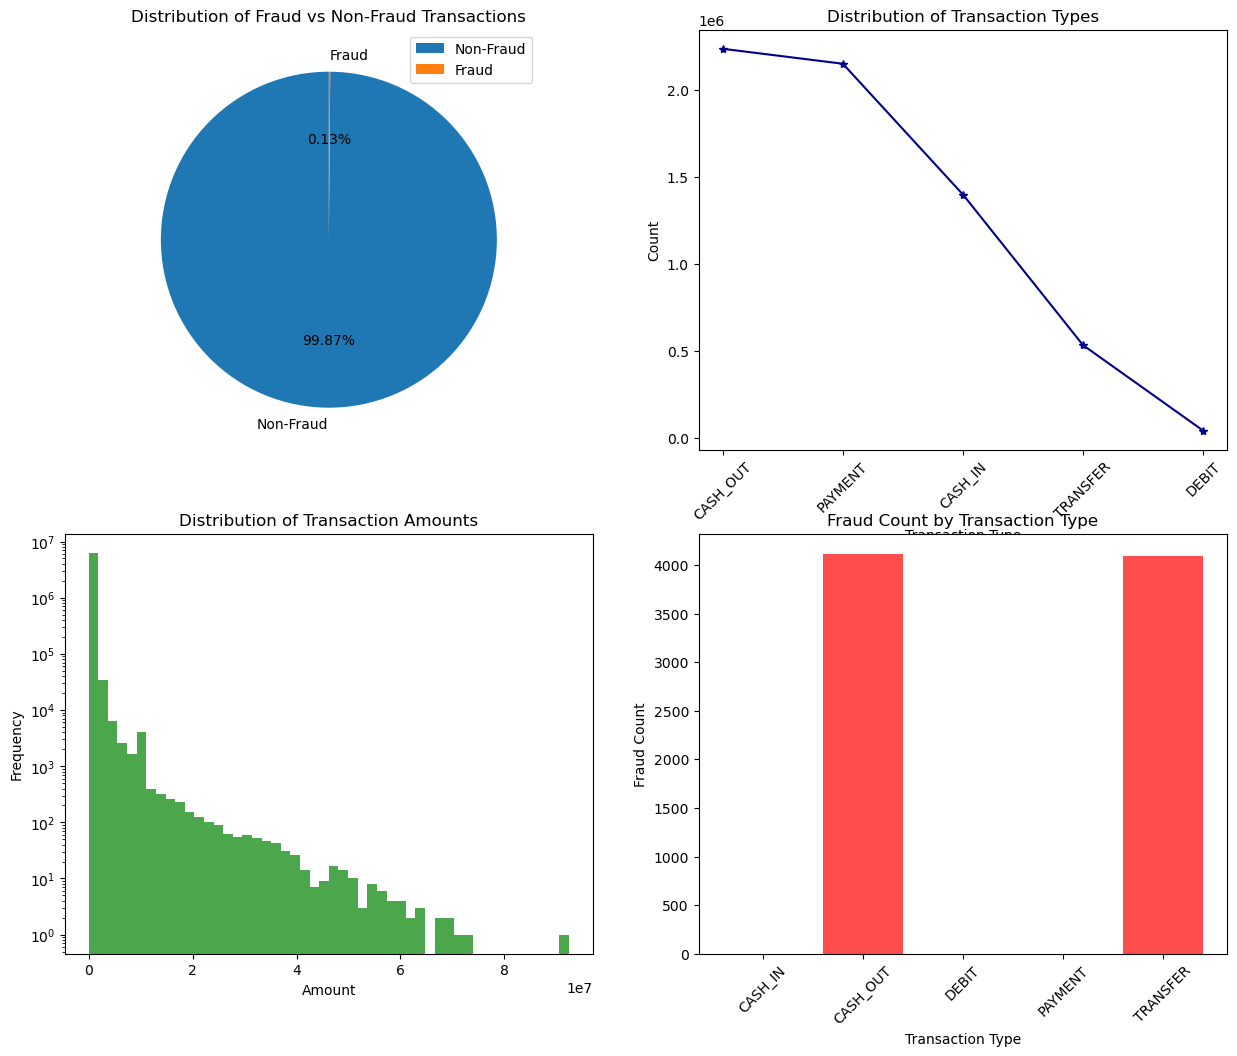

In [6]:
########## Data Visualization ##########
import matplotlib.pyplot as plt

# Create subplots for multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of Fraud vs Non-Fraud transactions
fraud_counts = df['isFraud'].value_counts()
axes[0, 0].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%', startangle=90)
axes[0, 0].set_title('Distribution of Fraud vs Non-Fraud Transactions')
axes[0, 0].legend()

# 2. Transaction types distribution
type_counts = df['type'].value_counts()
axes[0, 1].plot(type_counts.index, type_counts.values, color='darkblue', marker='*')
axes[0, 1].set_title('Distribution of Transaction Types')
axes[0, 1].set_xlabel('Transaction Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Amount distribution (log scale due to wide range)
axes[1, 0].hist(df['amount'], bins=50, alpha=0.7, color='green')
axes[1, 0].set_title('Distribution of Transaction Amounts')
axes[1, 0].set_xlabel('Amount')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_yscale('log')

# 4. Fraud by transaction type
fraud_by_type = df.groupby('type')['isFraud'].sum()
axes[1, 1].bar(fraud_by_type.index, fraud_by_type.values, color='red', alpha=0.7)
axes[1, 1].set_title('Fraud Count by Transaction Type')
axes[1, 1].set_xlabel('Transaction Type')
axes[1, 1].set_ylabel('Fraud Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.show()


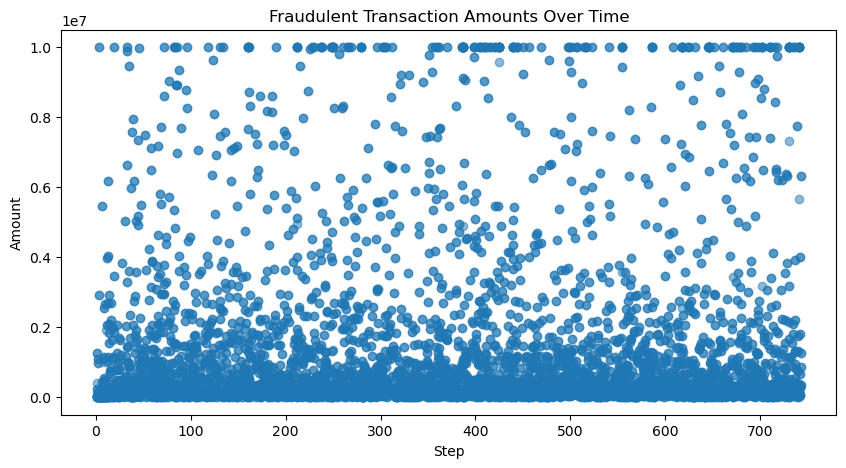

In [7]:
######### Fraud Data visualization ###########
fraud = df[df['isFraud'] == 1]
plt.figure(figsize=(10,5))
plt.plot(fraud['step'], fraud['amount'], linestyle='none', marker='o', alpha=0.5)
plt.title('Fraudulent Transaction Amounts Over Time')
plt.xlabel('Step')
plt.ylabel('Amount')
plt.show()


In [ ]:
df_processed = pd.get_dummies(df, columns=['type'], drop_first=True)

# The function takes the type column and creates new columns, 
# where each new column represents a possible category from the original type column.
# The values in these new columns are either 0 or 1 

X = df_processed.drop(columns=['isFraud', 'nameOrig', 'nameDest']) 
y = df_processed['isFraud']
# X.head()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix as cm 
import matplotlib.pyplot as plt

# Note: This cell is now primarily for imports
# The actual model training has been moved to the XGBoost cells below
print("Libraries imported successfully!")
print("RandomForestClassifier will be used for comparison with XGBoost")

<class 'pandas.core.frame.DataFrame'>
(1590655, 11)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

# Check class distribution before balancing
print("Original class distribution:")
print(y.value_counts())
print(f"Fraud percentage: {(y.sum() / len(y)) * 100:.3f}%")

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE balancing:")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced distribution: {np.bincount(y_balanced)}")

# Split the balanced dataset
x_train, x_test, y_train, y_test = train_test_split(X_balanced, y_balanced, random_state=42, test_size=0.25, stratify=y_balanced)

print(f"\nTraining set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Training set class distribution: {np.bincount(y_train)}")
print(f"Test set class distribution: {np.bincount(y_test)}")

KeyboardInterrupt: 

In [ ]:
########## XGBoost Model Training ##########
# XGBoost is faster than RandomForest and handles imbalanced data better
# Using optimized parameters for fraud detection

# Calculate scale_pos_weight for handling any remaining imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale pos weight: {scale_pos_weight}")

# Initialize XGBoost classifier with optimized parameters
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    max_depth=6,                    # Moderate depth to prevent overfitting
    learning_rate=0.1,              # Standard learning rate
    n_estimators=100,               # Fewer trees for faster training
    subsample=0.8,                  # Subsample to prevent overfitting
    colsample_bytree=0.8,           # Feature subsampling
    scale_pos_weight=scale_pos_weight,  # Handle any remaining imbalance
    random_state=42,
    n_jobs=-1,                      # Use all available cores
    verbosity=1                     # Show progress
)

# Train the model
print("Training XGBoost model...")
xgb_model.fit(x_train, y_train)

# Make predictions
y_pred = xgb_model.predict(x_test)
y_pred_proba = xgb_model.predict_proba(x_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
########## Model Evaluation and Visualization ##########
import seaborn as sns

# Create confusion matrix
cm_matrix = confusion_matrix(y_test, y_pred)

# Create subplots for visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_yticklabels(['Non-Fraud', 'Fraud'])

# 2. Feature Importance
feature_importance = xgb_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

# Plot top 10 most important features
top_features = importance_df.tail(10)
axes[1].barh(top_features['feature'], top_features['importance'])
axes[1].set_title('Top 10 Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Print confusion matrix details
tn, fp, fn, tp = cm_matrix.ravel()
print(f"\nConfusion Matrix Details:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# Calculate precision, recall, and F1-score manually
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nDetailed Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")

print(f"\nTop 5 Most Important Features:")
for i, row in importance_df.tail(5).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

In [ ]:
########## Training Time Comparison and Model Summary ##########
import time

# Compare training times between XGBoost and RandomForest on a smaller sample
sample_size = 10000  # Use smaller sample for fair comparison
X_sample = X_balanced[:sample_size]
y_sample = y_balanced[:sample_size]
x_train_sample, x_test_sample, y_train_sample, y_test_sample = train_test_split(
    X_sample, y_sample, test_size=0.25, random_state=42, stratify=y_sample
)

print("Training Time Comparison (on 10k samples):")
print("=" * 50)

# XGBoost timing
start_time = time.time()
xgb_quick = xgb.XGBClassifier(n_estimators=50, random_state=42, n_jobs=-1)
xgb_quick.fit(x_train_sample, y_train_sample)
xgb_time = time.time() - start_time
xgb_pred = xgb_quick.predict(x_test_sample)
xgb_accuracy = accuracy_score(y_test_sample, xgb_pred)

# RandomForest timing
start_time = time.time()
rf_quick = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_quick.fit(x_train_sample, y_train_sample)
rf_time = time.time() - start_time
rf_pred = rf_quick.predict(x_test_sample)
rf_accuracy = accuracy_score(y_test_sample, rf_pred)

print(f"XGBoost Training Time: {xgb_time:.2f} seconds")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"RandomForest Training Time: {rf_time:.2f} seconds")
print(f"RandomForest Accuracy: {rf_accuracy:.4f}")
print(f"Speed Improvement: {rf_time/xgb_time:.2f}x faster with XGBoost")

print("\n" + "=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model: XGBoost Classifier")
print(f"Dataset: Balanced using SMOTE")
print(f"Training Samples: {len(x_train):,}")
print(f"Test Samples: {len(x_test):,}")
print(f"Features: {x_train.shape[1]}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
